In [63]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [103]:

data = pd.read_csv("../data/WineQT.csv")

In [104]:
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [106]:
df = pd.read_csv(url,sep=";",header=None, usecols=[0,1,2])

In [107]:
df

,0,1,2
0,fixed acidity,volatile acidity,citric acid
1,7.4,0.7,0
2,7.8,0.88,0
3,7.8,0.76,0.04
4,11.2,0.28,0.56
...,...,...,...
1595,6.2,0.6,0.08
1596,5.9,0.55,0.1
1597,6.3,0.51,0.13
1598,5.9,0.645,0.12


In [109]:
df.columns=["Class_Label","Alcohol", "Malic_Acid"]


In [110]:
df

,Class_Label,Alcohol,Malic_Acid
0,fixed acidity,volatile acidity,citric acid
1,7.4,0.7,0
2,7.8,0.88,0
3,7.8,0.76,0.04
4,11.2,0.28,0.56
...,...,...,...
1595,6.2,0.6,0.08
1596,5.9,0.55,0.1
1597,6.3,0.51,0.13
1598,5.9,0.645,0.12


In [111]:
df = df.drop(df.index[:1])

In [112]:
df

,Class_Label,Alcohol,Malic_Acid
1,7.4,0.7,0
2,7.8,0.88,0
3,7.8,0.76,0.04
4,11.2,0.28,0.56
5,7.4,0.7,0
...,...,...,...
1595,6.2,0.6,0.08
1596,5.9,0.55,0.1
1597,6.3,0.51,0.13
1598,5.9,0.645,0.12


In [113]:
df['Alcohol'].dtype

dtype('O')

In [114]:
df["Alcohol"] = pd.to_numeric(df["Alcohol"], errors='coerce')

<Axes: xlabel='Alcohol', ylabel='Density'>

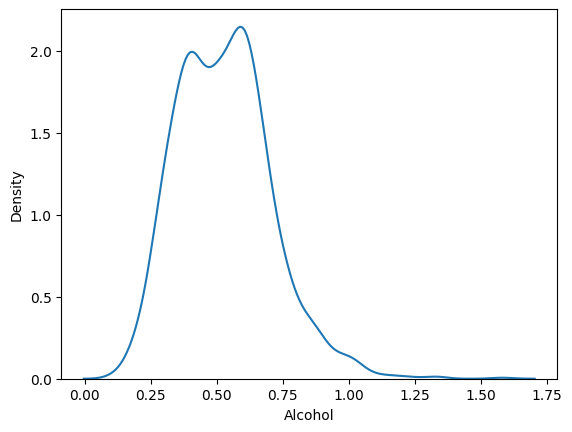

In [115]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic_Acid', ylabel='Density'>

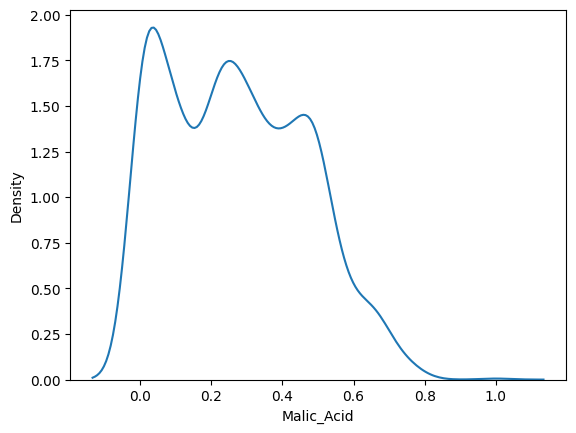

In [116]:
df["Malic_Acid"] = pd.to_numeric(df["Malic_Acid"], errors='coerce')
sns.kdeplot(df['Malic_Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic_Acid'>

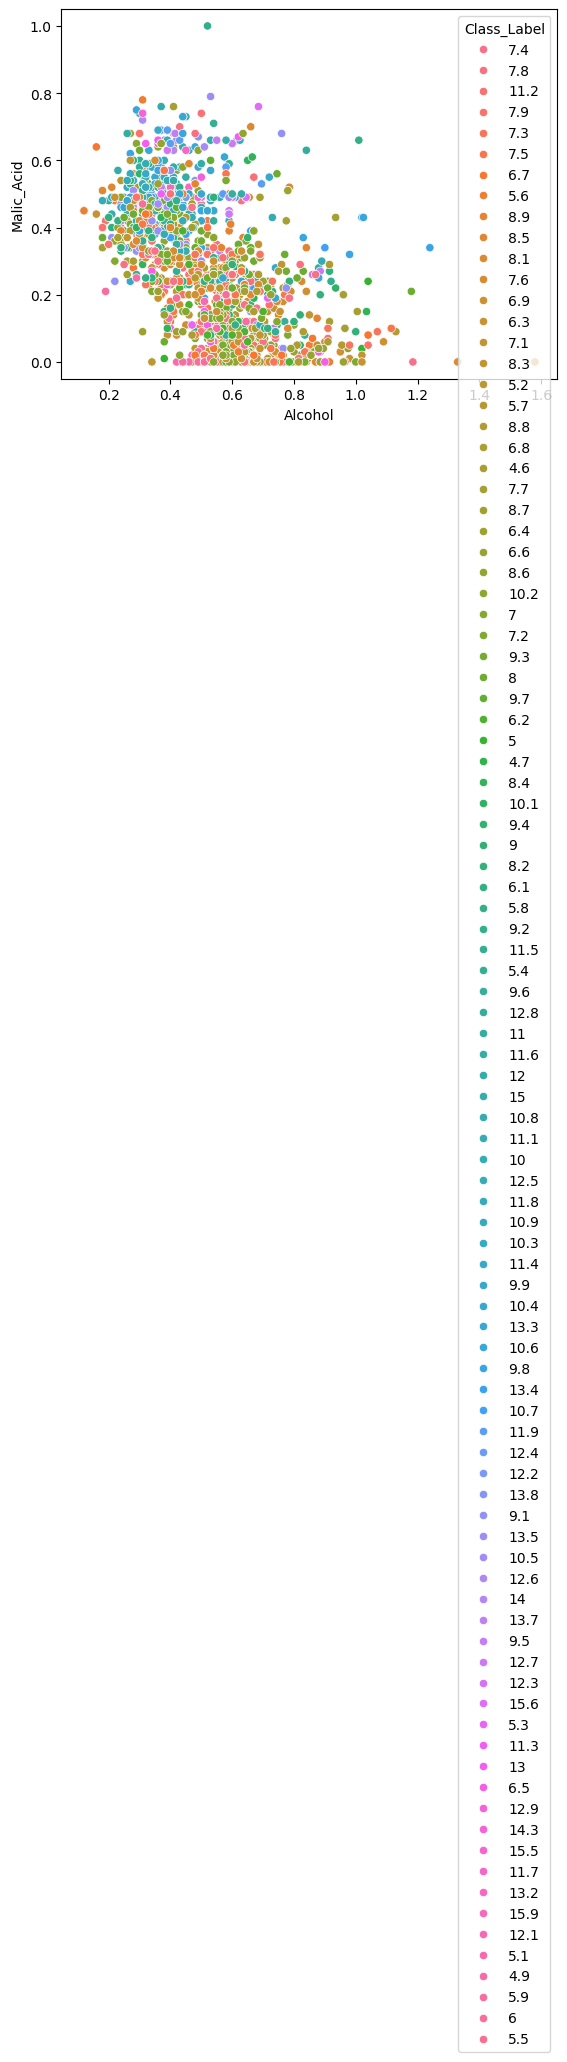

In [126]:
color_dict = {1: 'red', 2: 'blue', 3: 'green'}

sns.scatterplot(x=df['Alcohol'], y=df['Malic_Acid'], hue=df['Class_Label'])


In [150]:
from sklearn.model_selection import train_test_split
x_train, x_test , y_train, y_test = train_test_split(df.drop("Class_Label", axis =1), df['Class_Label'], test_size=0.3,random_state=0)

In [151]:
x_train.shape, x_test.shape

((1119, 2), (480, 2))

In [152]:
from sklearn.preprocessing import MinMaxScaler

In [153]:
scaler = MinMaxScaler()

In [154]:
print(type(x_test))
print(x_test.shape)


<class 'pandas.core.frame.DataFrame'>
(480, 2)


In [155]:
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [156]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [158]:
np.round(x_train.describe(),1)

,Alcohol,Malic_Acid
count,1119.0,1119.0
mean,0.5,0.3
std,0.2,0.2
min,0.1,0.0
25%,0.4,0.1
50%,0.5,0.3
75%,0.6,0.4
max,1.6,1.0


In [160]:
np.round(x_train_scaled.describe(),1)

,Alcohol,Malic_Acid
count,1119.0,1119.0
mean,0.3,0.3
std,0.1,0.2
min,0.0,0.0
25%,0.2,0.1
50%,0.3,0.3
75%,0.4,0.4
max,1.0,1.0


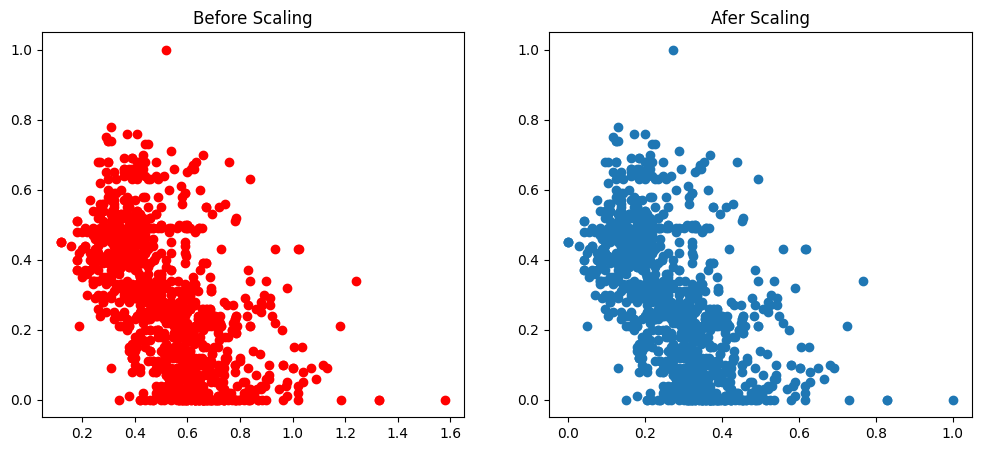

In [171]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(x_train['Alcohol'],x_train['Malic_Acid'],c='red')
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Alcohol'], x_train_scaled['Malic_Acid'])
ax2.set_title("Afer Scaling")
plt.show()